## **Customer shopping**

### Contents
1. Load data and check size
2. Drop unused columns
3. Check missing values, duplicates, and dtypes
4. Split by Gender
5. EDA — Item Purchased, Size, Category, Review Rating, Purchase Amount
6. Multivariate — correlation heatmap
7. Feature engineering — dummy variables, scaling, binning
8. Summary

In [49]:
# TODO: import pandas, numpy, matplotlib.pyplot, and seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
# TODO: load shopping_trends.csv with pd.read_csv(), then show the first 5 rows
df = pd.read_csv('shopping_trends.csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [51]:
# TODO: check the dataset size with df.shape
df.shape

(3900, 19)

In [52]:
# TODO: drop the Customer ID column  
df = df.drop(columns=['Customer ID'])
df

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly


### **Data quality**

Check dtypes, missing values, and duplicate rows before plotting.

In [53]:
# TODO: check columns, dtypes, and non-null counts with df.info()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       3900 non-null   int64  
 1   Gender                    3900 non-null   str    
 2   Item Purchased            3900 non-null   str    
 3   Category                  3900 non-null   str    
 4   Purchase Amount (USD)     3900 non-null   int64  
 5   Location                  3900 non-null   str    
 6   Size                      3900 non-null   str    
 7   Color                     3900 non-null   str    
 8   Season                    3900 non-null   str    
 9   Review Rating             3900 non-null   float64
 10  Subscription Status       3900 non-null   str    
 11  Payment Method            3900 non-null   str    
 12  Shipping Type             3900 non-null   str    
 13  Discount Applied          3900 non-null   str    
 14  Promo Code Used    

In [54]:
# TODO: check missing values with df.isnull().sum()
df.isnull().sum()

Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [55]:
# TODO: check duplicate rows with df.duplicated().sum()
df.duplicated().sum()

np.int64(0)

In [56]:
# TODO: univariate — describe numeric columns
df.describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,25.351538
std,15.207589,23.685392,0.716223,14.447125
min,18.000000,20.000000,2.500000,1.000000
25%,31.000000,39.000000,3.100000,13.000000
50%,44.000000,60.000000,3.700000,25.000000
75%,57.000000,81.000000,4.400000,38.000000
max,70.000000,100.000000,5.000000,50.000000


In [57]:
# TODO: split the data into male_df and female_df using df[df['Gender']==...]
male_df = df[df['Gender'] == 'Male']
female_df = df[df['Gender'] == 'Female']

## **EDA**

### **Item Purchased**

In [58]:
# TODO: count top items with value_counts().reset_index() for male, female, and all customers
top_item_all = df['Item Purchased'].value_counts().reset_index(name='count')
top_item_m = male_df['Item Purchased'].value_counts().reset_index(name='count')
top_item_f = female_df['Item Purchased'].value_counts().reset_index(name='count')

print(top_item_all)
print(top_item_m)
print(top_item_f)


   Item Purchased  count
0          Blouse    171
1           Pants    171
2         Jewelry    171
3           Shirt    169
4           Dress    166
5         Sweater    164
6          Jacket    163
7            Coat    161
8      Sunglasses    161
9            Belt    161
10        Sandals    160
11          Socks    159
12          Skirt    158
13         Shorts    157
14          Scarf    157
15            Hat    154
16        Handbag    153
17         Hoodie    151
18          Shoes    150
19        T-shirt    147
20       Sneakers    145
21          Boots    144
22       Backpack    143
23         Gloves    140
24          Jeans    124
   Item Purchased  count
0           Pants    123
1         Jewelry    119
2         Sweater    114
3            Coat    114
4           Dress    114
5           Scarf    112
6           Shirt    110
7          Shorts    109
8           Skirt    109
9          Jacket    109
10       Backpack    106
11           Belt    106
12         Blouse    105


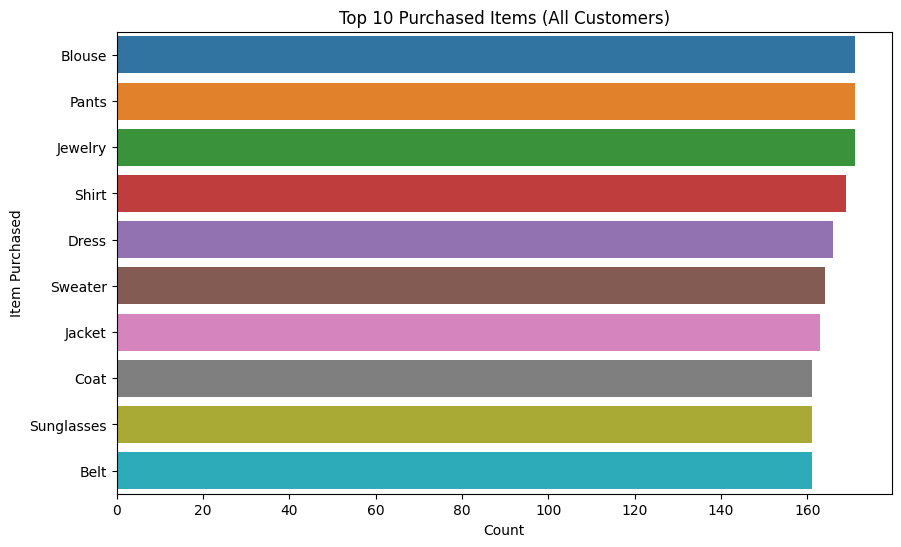

In [59]:
# TODO: plot a horizontal bar chart of the top 10 items with sns.barplot()
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_item_all.head(10),
    x='count',
    y='Item Purchased',
    hue='Item Purchased',
    dodge=False,
    legend=False
)
plt.title("Top 10 Purchased Items (All Customers)")
plt.xlabel('Count')
plt.ylabel('Item Purchased')
plt.show()

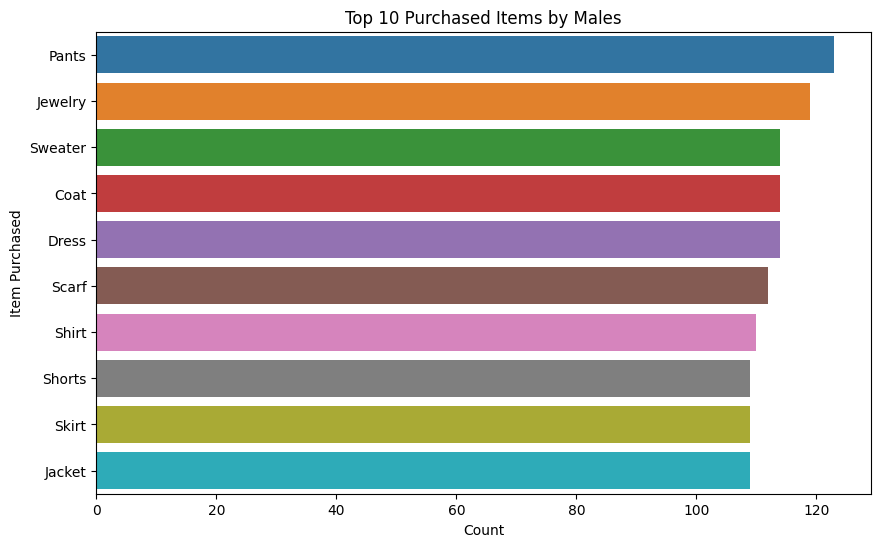

In [60]:
# TODO: plot a horizontal bar chart of the top 10 items for males with sns.barplot()
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_item_m.head(10),
    x='count',
    y='Item Purchased',
    hue='Item Purchased',
    dodge=False,
    legend=False
)
plt.title("Top 10 Purchased Items by Males")
plt.xlabel('Count')
plt.ylabel('Item Purchased')
plt.show()

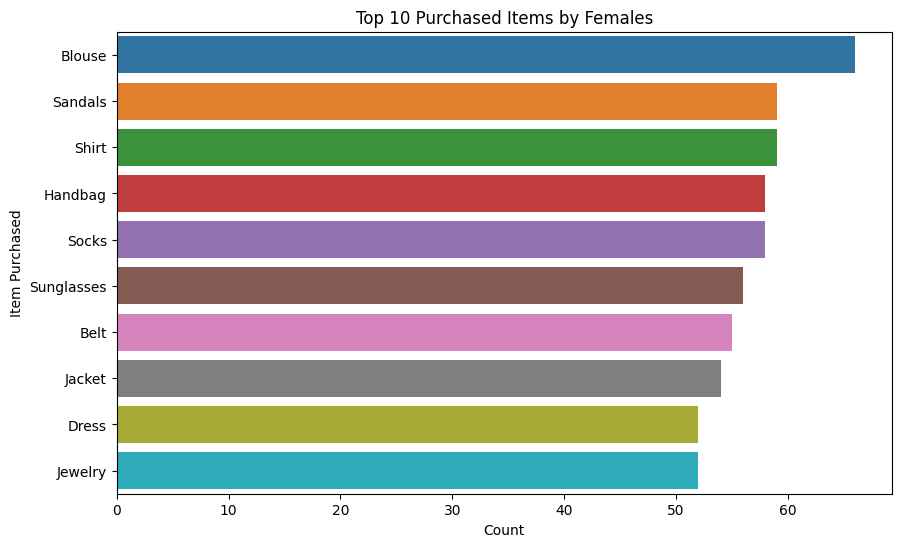

In [61]:
# TODO: plot a horizontal bar chart of the top 10 items for females with sns.barplot()
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_item_f.head(10),
    x='count',
    y='Item Purchased',
    hue='Item Purchased',
    dodge=False,
    legend=False
)
plt.title("Top 10 Purchased Items by Females")
plt.xlabel('Count')
plt.ylabel('Item Purchased')
plt.show()

In [62]:
# TODO: count Size with value_counts() for all customers
size_all = df['Size'].value_counts()
print(size_all)

Size
M     1755
L     1053
S      663
XL     429
Name: count, dtype: int64


In [63]:
# TODO: count Size with value_counts() for male_df and female_df
size_m = male_df['Size'].value_counts()
size_f = female_df['Size'].value_counts()
print("Male Sizes:\n", size_m)
print("\nFemale Sizes:\n", size_f)

Male Sizes:
 Size
M     1165
L      716
S      476
XL     295
Name: count, dtype: int64

Female Sizes:
 Size
M     590
L     337
S     187
XL    134
Name: count, dtype: int64


### **Category**

In [64]:
# TODO: count Category with value_counts().reset_index() for all customers
ctg = df['Category'].value_counts().reset_index(name='count')
print(ctg)

      Category  count
0     Clothing   1737
1  Accessories   1240
2     Footwear    599
3    Outerwear    324


In [65]:
# TODO: count Category with value_counts().reset_index() for male_df and female_df
ctg_m = male_df['Category'].value_counts().reset_index(name='count')
ctg_f = female_df['Category'].value_counts().reset_index(name='count')
print(ctg_m)
print(ctg_f)

      Category  count
0     Clothing   1181
1  Accessories    848
2     Footwear    400
3    Outerwear    223
      Category  count
0     Clothing    556
1  Accessories    392
2     Footwear    199
3    Outerwear    101


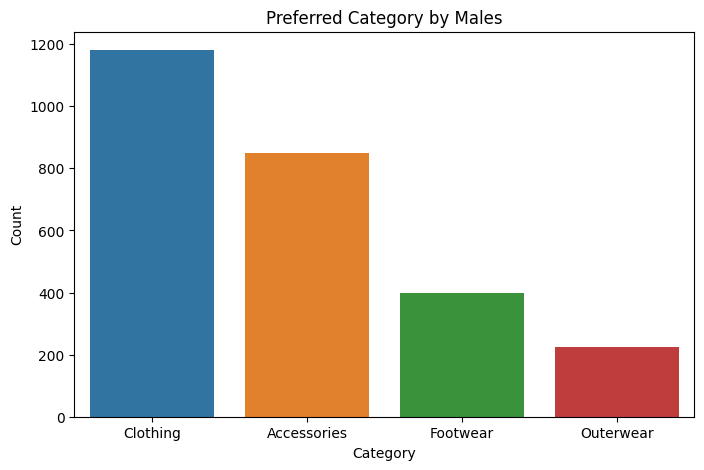

In [66]:
# TODO: plot a bar chart of preferred Category for males with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
    data=ctg_m,
    x='Category',
    y='count',
    hue='Category',
    dodge=False,
    legend=False
)
plt.title("Preferred Category by Males")
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

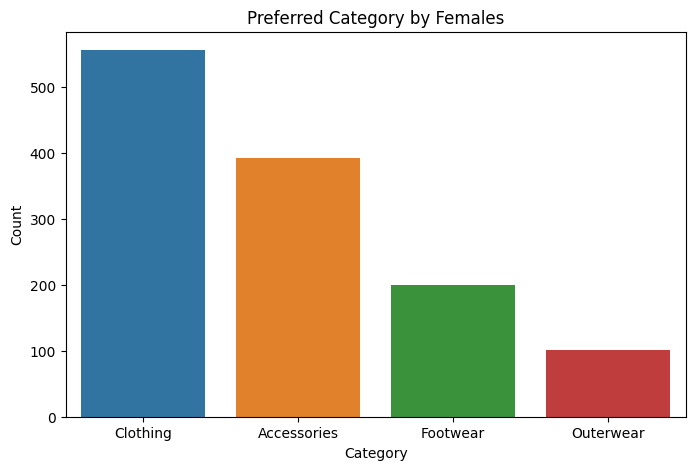

In [67]:
# TODO: plot a bar chart of preferred Category for females with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
    data=ctg_f,
    x='Category',
    y='count',
    hue='Category',
    dodge=False,
    legend=False
)
plt.title("Preferred Category by Females")
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

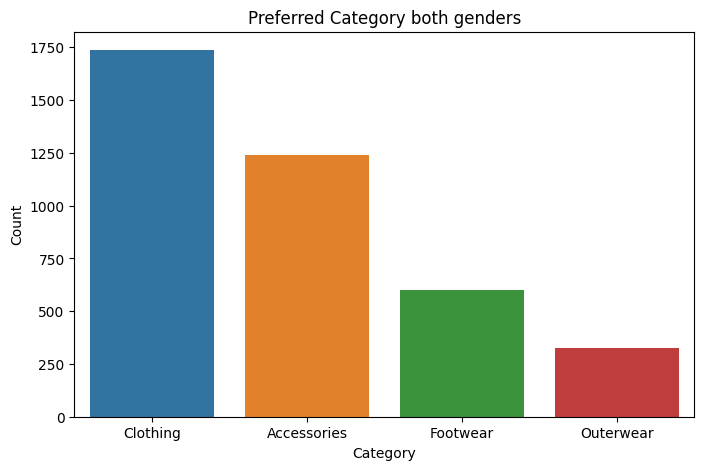

In [86]:
# TODO: plot a bar chart of preferred Category for both genders with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
    data=ctg,
    x='Category',
    y='count',
    hue='Category',
    dodge=False,
    legend=False
)
plt.title("Preferred Category both genders")
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()


In [87]:
# TODO: create waffle_data_m and waffle_data_f from Category value_counts()
waffle_data_m = dict(male_df['Category'].value_counts())
# TODO: create waffle_data_f from female_df['Category'].value_counts()
waffle_data_f = dict(female_df['Category'].value_counts())


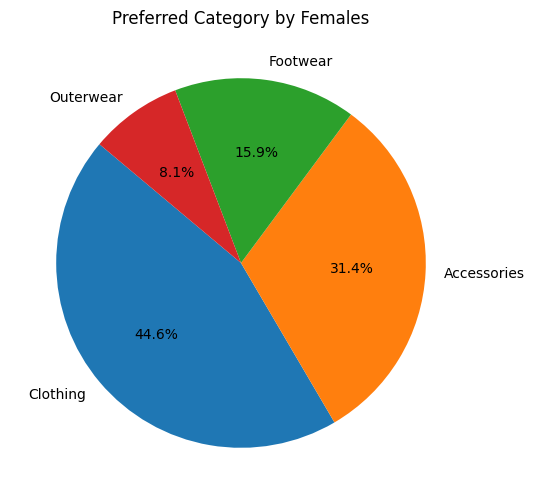

In [88]:
# TODO: plot a pie chart of preferred Category for females with plt.pie()
plt.figure(figsize=(6, 6))
plt.pie(
    waffle_data_f.values(),
    labels=waffle_data_f.keys(),
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Preferred Category by Females")
plt.show()

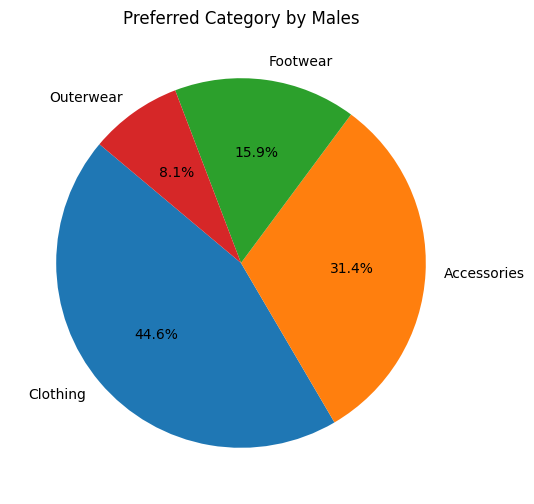

In [89]:
# TODO: plot a pie chart of preferred Category for males with plt.pie()
plt.figure(figsize=(6, 6))
plt.pie(
    waffle_data_f.values(),
    labels=waffle_data_m.keys(),
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Preferred Category by Males")
plt.show()

### **Review ratings**

In [90]:
# TODO: filter female Clothing rows, then mean of Review Rating
cr_f = female_df[female_df['Category'] == 'Clothing']
avg_cr_f = cr_f['Review Rating'].mean()

print(cr_f)
print(avg_cr_f)

      Age  Gender Item Purchased  Category  Purchase Amount (USD)  \
2652   23  Female         Shorts  Clothing                     20   
2653   67  Female         Blouse  Clothing                     36   
2656   52  Female         Shorts  Clothing                     76   
2657   52  Female          Dress  Clothing                     81   
2660   24  Female          Pants  Clothing                     85   
...   ...     ...            ...       ...                    ...   
3889   57  Female          Dress  Clothing                     65   
3890   35  Female          Shirt  Clothing                     81   
3891   36  Female          Dress  Clothing                     30   
3894   66  Female          Skirt  Clothing                     78   
3895   40  Female         Hoodie  Clothing                     28   

            Location Size      Color  Season  Review Rating  \
2652        Maryland    L       Cyan  Summer            3.3   
2653       Wisconsin    L   Lavender    Fall 

In [91]:
# TODO: filter male Clothing rows, then mean of Review Rating
cr_m = male_df[male_df['Category'] == 'Clothing']
avg_cr_m = cr_m['Review Rating'].mean()
print(cr_m)
print(avg_cr_m)

      Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0      55   Male         Blouse  Clothing                     53   
1      19   Male        Sweater  Clothing                     64   
2      50   Male          Jeans  Clothing                     73   
4      45   Male         Blouse  Clothing                     49   
6      63   Male          Shirt  Clothing                     85   
...   ...    ...            ...       ...                    ...   
2640   30   Male          Skirt  Clothing                     75   
2644   25   Male          Pants  Clothing                     83   
2646   33   Male        T-shirt  Clothing                     56   
2648   51   Male          Pants  Clothing                     84   
2650   20   Male          Socks  Clothing                     35   

           Location Size      Color  Season  Review Rating  \
0          Kentucky    L       Gray  Winter            3.1   
1             Maine    L     Maroon  Winter            3.1 

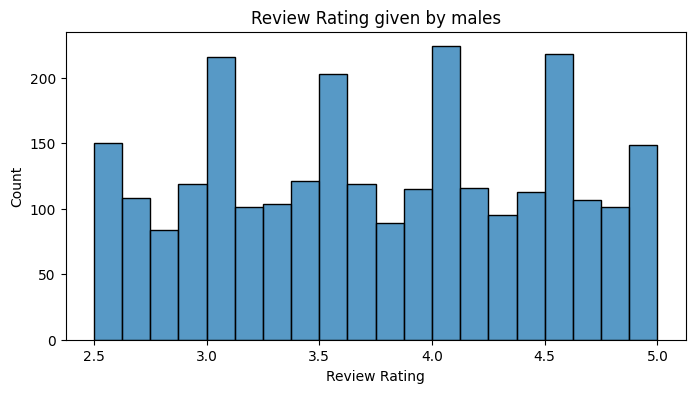

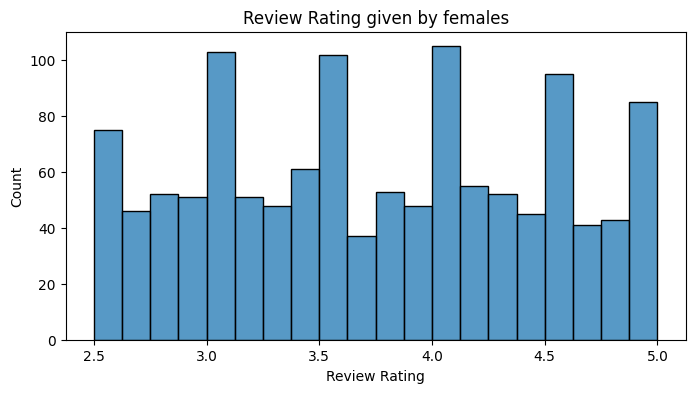

In [93]:
# TODO: plot Review Rating histograms for males and females with sns.histplot()
# males
plt.figure(figsize=(8, 4))
sns.histplot(data=male_df, x='Review Rating', bins=20)
plt.title("Review Rating given by males")
plt.show()

# females
plt.figure(figsize=(8, 4))
sns.histplot(data=female_df, x='Review Rating', bins=20)
plt.title("Review Rating given by females")
plt.show()

In [94]:
# TODO: count Review Rating with value_counts() for male Clothing (cr_m)
cr_m['Review Rating'].value_counts()

Review Rating
3.7    61
3.4    59
2.7    55
2.9    55
4.0    52
4.2    52
3.9    52
3.3    49
3.0    49
4.9    48
4.1    48
3.5    48
3.1    46
4.7    46
4.6    46
3.6    46
4.8    46
2.6    45
4.3    45
4.4    43
3.2    41
2.8    41
3.8    39
4.5    36
2.5    17
5.0    16
Name: count, dtype: int64

### **Purchase Amount (USD)**

In [95]:
# TODO: sum Purchase Amount (USD) for males
m_tpa = male_df['Purchase Amount (USD)'].sum()
print("Male Total Purchase Amount:", m_tpa)
# # TODO: sum Purchase Amount (USD) for females
f_tpa = female_df['Purchase Amount (USD)'].sum()
print("Female Total Purchase Amount:", f_tpa)

Male Total Purchase Amount: 157890
Female Total Purchase Amount: 75191


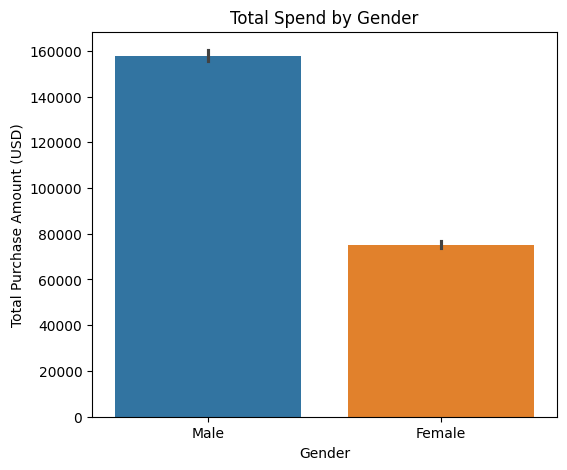

In [96]:
# TODO: plot total spend by gender with sns.barplot()
plt.figure(figsize=(6, 5))
sns.barplot(
    data=df,
    x='Gender',
    y='Purchase Amount (USD)',
    estimator=np.sum,
    hue='Gender',
    dodge=False,
    legend=False
)
plt.title("Total Spend by Gender")
plt.xlabel('Gender')
plt.ylabel('Total Purchase Amount (USD)')
plt.show()

In [100]:
# TODO: filter female_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_f = cr_f
ca_f = female_df[female_df['Category'] == 'Accessories']
cf_f = female_df[female_df['Category'] == 'Footwear']
co_f = female_df[female_df['Category'] == 'Outerwear']
print(ca_f)
print(cf_f)
print(co_f)

      Age  Gender Item Purchased     Category  Purchase Amount (USD)  \
2655   26  Female     Sunglasses  Accessories                     83   
2658   52  Female        Handbag  Accessories                     47   
2664   22  Female        Jewelry  Accessories                     84   
2669   39  Female           Belt  Accessories                     28   
2670   30  Female     Sunglasses  Accessories                     44   
...   ...     ...            ...          ...                    ...   
3892   35  Female        Jewelry  Accessories                     86   
3893   21  Female            Hat  Accessories                     64   
3896   52  Female       Backpack  Accessories                     49   
3897   46  Female           Belt  Accessories                     33   
3899   52  Female        Handbag  Accessories                     81   

           Location Size   Color  Season  Review Rating Subscription Status  \
2655        Wyoming    M    Gray  Summer            3.4 

In [101]:
# TODO: filter male_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_m = cr_m
ca_m = male_df[male_df['Category'] == 'Accessories']
cf_m = male_df[male_df['Category'] == 'Footwear']
co_m = male_df[male_df['Category'] == 'Outerwear']
print(ca_m)
print(cf_m)
print(co_m)

      Age Gender Item Purchased     Category  Purchase Amount (USD)  \
9      57   Male        Handbag  Accessories                     31   
16     25   Male     Sunglasses  Accessories                     36   
26     38   Male        Jewelry  Accessories                     20   
28     54   Male        Handbag  Accessories                     94   
30     57   Male        Jewelry  Accessories                     31   
...   ...    ...            ...          ...                    ...   
2641   25   Male     Sunglasses  Accessories                     60   
2642   39   Male           Belt  Accessories                     87   
2643   49   Male         Gloves  Accessories                     41   
2645   23   Male          Scarf  Accessories                     81   
2649   23   Male         Gloves  Accessories                     21   

            Location Size    Color  Season  Review Rating Subscription Status  \
9           Missouri    M     Pink  Spring            4.8         

In [102]:
# TODO: create pcu dict from Promo Code Used value_counts()
pcu = dict(df['Promo Code Used'].value_counts())
print(pcu)

{'No': np.int64(2223), 'Yes': np.int64(1677)}


### **Relationships (multivariate)**

Numeric columns only: Age, Purchase Amount (USD), Review Rating, Previous Purchases.

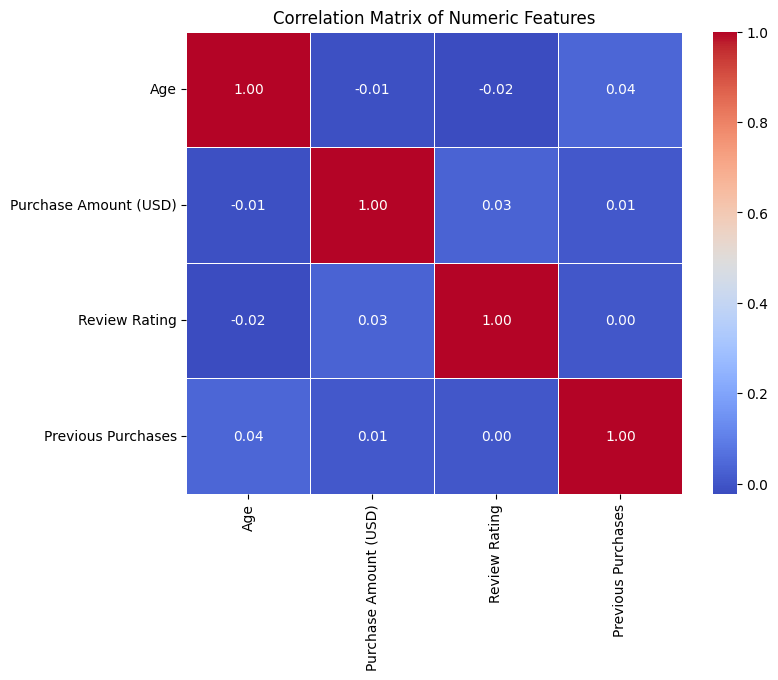

In [103]:
# TODO: compute correlation with df.corr(numeric_only=True), then plot a heatmap with sns.heatmap()
plt.figure(figsize=(8, 6))
numeric_cols = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

### **Feature engineering**

Dummy variables for columns with few levels. Scale numeric columns (keep originals). Bin purchase amount.

In [104]:
# TODO: dummy variables for Gender, Size, and Category with pd.get_dummies()
df = pd.get_dummies(df, columns=['Gender', 'Size', 'Category'], dtype=int)
df.head()

,Age,Item Purchased,Purchase Amount (USD),Location,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,...,Gender_Female,Gender_Male,Size_L,Size_M,Size_S,Size_XL,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear
0,55,Blouse,53,Kentucky,Gray,Winter,3.1,Yes,Credit Card,Express,...,0,1,1,0,0,0,0,1,0,0
1,19,Sweater,64,Maine,Maroon,Winter,3.1,Yes,Bank Transfer,Express,...,0,1,1,0,0,0,0,1,0,0
2,50,Jeans,73,Massachusetts,Maroon,Spring,3.1,Yes,Cash,Free Shipping,...,0,1,0,0,1,0,0,1,0,0
3,21,Sandals,90,Rhode Island,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,...,0,1,0,1,0,0,0,0,1,0
4,45,Blouse,49,Oregon,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,...,0,1,0,1,0,0,0,1,0,0


In [107]:
# TODO: use MinMaxScaler on Purchase Amount (USD) and StandardScaler on Age (keep original columns)
from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler_minmax = MinMaxScaler()
scaler_std = StandardScaler()

df['Purchase_Amount_Scaled'] = scaler_minmax.fit_transform(df[['Purchase Amount (USD)']])
df['Age_Scaled'] = scaler_std.fit_transform(df[['Age']])
print(df[['Purchase_Amount_Scaled', 'Purchase Amount (USD)', 'Age_Scaled', 'Age']].head())

   Purchase_Amount_Scaled  Purchase Amount (USD)  Age_Scaled  Age
0                  0.4125                     53    0.718913   55
1                  0.5500                     64   -1.648629   19
2                  0.6625                     73    0.390088   50
3                  0.8750                     90   -1.517099   21
4                  0.3625                     49    0.061263   45


In [110]:
# TODO: use pd.cut() to bin Purchase Amount (USD) into Low / Medium / High
bins = [0, 50, 100, df['Purchase Amount (USD)'].max() + 1]
labels = ['Low', 'Medium', 'High']
df['Amount_bin'] = pd.cut(df['Purchase Amount (USD)'], bins=bins, labels=labels, right=False)
print(df['Amount_bin'].value_counts())


Amount_bin
Medium    2398
Low       1466
High        36
Name: count, dtype: int64


### **Summary**

Write 4–5 insights from the plots. These are associations, not causal claims.

Examples to check:
- Which items and categories are most common for males vs females?
- Do males and females spend a similar total amount?
- Is Review Rating similar across genders?
- How often is a promo code used?

# TODO: write insights
- 
- 
- 
- 

Caveat: correlation is not causation.